In [1]:
import sys
!{sys.executable} -m pip install python-dotenv

In [2]:
import os
from dotenv import load_dotenv

# 1. Cargar el archivo .env
load_dotenv()

# 2. Intentar leer la variable
api_key_test = os.getenv('WEATHER_API_KEY')

if api_key_test:
    # Mostramos solo los primeros 4 caracteres por seguridad
    print(f"✅ ¡Éxito! API Key detectada. Empieza por: {api_key_test[:4]}...")
else:
    print("❌ Error: No se pudo leer la API Key. Revisa el nombre dentro del archivo .env")

✅ ¡Éxito! API Key detectada. Empieza por: tu_l...


/tmp/ipykernel_4930/3318037167.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Ciudad", y="Humedad (%)", data=df, palette="Blues_d")


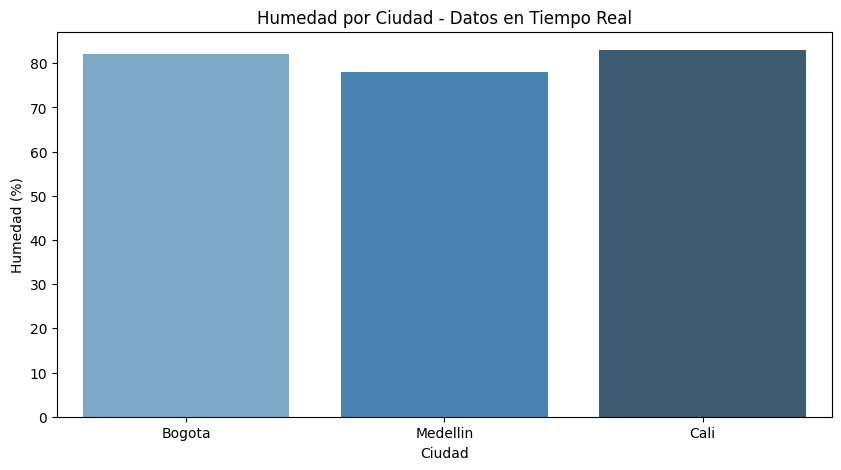

,Ciudad,Temp (°C),Humedad (%),Presion (hPa),Viento (m/s)
0,Bogota,15.10,82,1015,0.89
1,Medellin,19.42,78,1015,3.60
2,Cali,20.55,83,1012,1.03


In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

# 1. Configuración y Extracción
API_KEY = os.getenv('WEATHER_API_KEY')
#Validacion de seguridad
if not API_KEY:
    print("Error: No se encontró la API KEY")

else: 
    # Configuración y estracción
    CIUDADES = ["Bogota", "Medellin", "Cali"]
    datos = []

    for ciudad in CIUDADES:
        url = f"http://api.openweathermap.org/data/2.5/weather?q={ciudad},CO&appid={API_KEY}&units=metric"
        res = requests.get(url).json()

        # Validación extra en caso de que falle la API
        if res.get("cod") ==200:
            datos.append({
                "Ciudad": ciudad,
                "Temp (°C)": res['main']['temp'],
                "Humedad (%)": res['main']['humidity'],
                "Presion (hPa)": res['main']['pressure'],
                "Viento (m/s)": res['wind']['speed']
            })
        else:
            print(f"Error al obtener datos de {ciudad}: {res.get('message')}")

    # 2. Procesamiento con Pandas
    df = pd.DataFrame(datos)
    df.to_csv("dashboard_clima.csv", index=False)

    # 3. Visualización (Dashboard rápido)
    plt.figure(figsize=(10, 5))
    sns.barplot(x="Ciudad", y="Humedad (%)", data=df, palette="Blues_d")
    plt.title("Humedad por Ciudad - Datos en Tiempo Real")
    plt.show()

    df # Muestra la tabla final

Iniciando consulta a la API...
✅ Datos de Bogota obtenidos correctamente.
✅ Datos de Medellin obtenidos correctamente.
✅ Datos de Cali obtenidos correctamente.


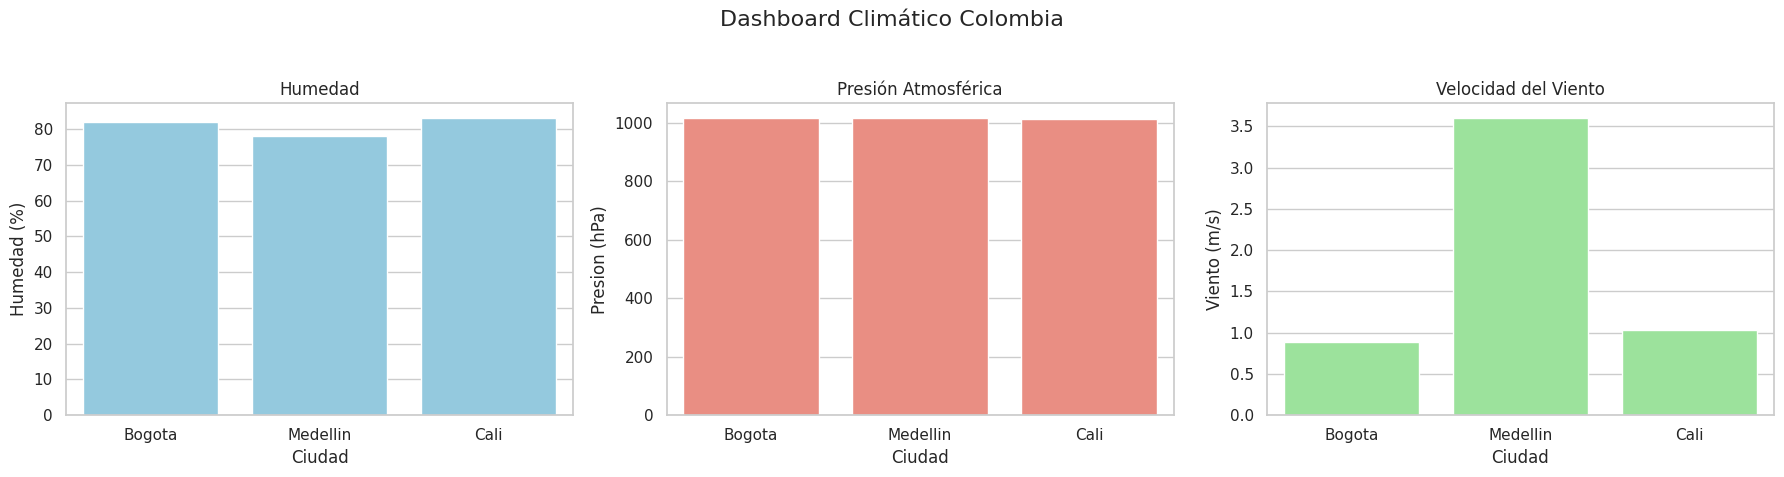


Proceso exitoso. Archivo guardado en: /home/jppl0/proyecto_datos/reporte_clima_final.csv


,Ciudad,Temperatura (°C),Humedad (%),Presion (hPa),Viento (m/s)
0,Bogota,15.10,82,1015,0.89
1,Medellin,19.43,78,1016,3.60
2,Cali,20.55,83,1012,1.03
